# Рекомендательная система для магазина — исследование данных

Данные: [RetailRocket ecommerce dataset](https://www.kaggle.com/datasets/retailrocket/ecommerce-dataset) (открытый). Журнал событий интернет-магазина за ~4.5 месяца 2015 года.

Notebook воспроизводимый: все числа считаются кодом из `data/`. Тяжёлая логика — в `src/second_year/`, здесь только вызовы и графики. Перед запуском нужен `python scripts/build_dataset.py`.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / 'src'))

%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd

from second_year.config import load_config
from second_year import eda
from second_year.data.load import load_events
from second_year.preprocessing.interactions import load_interactions
from second_year.preprocessing.properties import load_metadata_snapshots
from second_year.preprocessing.categories import load_category_paths
from second_year.split.temporal import describe_windows

pd.set_option('display.width', 140)
cfg = load_config()
events_raw = load_events(cfg)          # сырой events.csv, как есть
itx = load_interactions(cfg)           # processed: +ts, +weight, +is_bot, +split, -460 дублей
meta = load_metadata_snapshots(cfg)
paths = load_category_paths(cfg)
len(events_raw), len(itx)

(2756101, 2755641)

## 1. Постановка задачи

**Объект рекомендации** — товар (`itemid`).
**Пользовательская сущность** — визитор (`visitorid`); это идентификатор браузера/сессии, не аккаунт.
**Взаимодействие** — событие одного из трёх типов: `view`, `addtocart`, `transaction`. Явных оценок нет — обратная связь неявная (implicit feedback).
**Целевое действие** — сильное взаимодействие: `addtocart` или `transaction` (покупка — основной интерес бизнеса, `addtocart` — близкий по смыслу сигнал намерения). `view` — слабый сигнал и история пользователя.

**Что выдаём** — Top-N персональных рекомендаций по `visitorid`: `recommend(visitorid) -> [itemid, ...]`.

**Что доступно на момент рекомендации t** — все события с `ts < t` и срез свойств товаров (`categoryid`, `available`) на дату `<= t`. Цены, выручки и количества в датасете нет — денежные бизнес-метрики на этих данных недоступны.

### Offline ML-метрики

Постановка — Top-N recommendation с бинарной релевантностью (было сильное взаимодействие или нет), поэтому:

- **Recall@K** — какую долю товаров, с которыми пользователь реально провзаимодействует, мы показали в топ-K. Основная метрика: у пользователя обычно 1–2 релевантных товара, важно их «поймать».
- **NDCG@K** — то же, но с учётом позиции попадания в списке; список выдаётся упорядоченным, позиция важна.
- **HitRate@K** — доля пользователей, у которых хотя бы одно попадание; простая и понятная для отчёта величина.
- **MAP@K** — средняя точность; диагностическая, когда релевантных товаров несколько.
- **Coverage** — какую долю каталога модель вообще рекомендует; ловит вырождение в «топ популярного всем».

Precision@K для этого датасета малоинформативен (при 1–2 релевантных товарах его потолок ~ 1/K), берём его только как второстепенный.

Offline-метрика ≠ рост выручки: она измеряет воспроизведение уже наблюдавшегося поведения под старой выдачей магазина. Коммерческий эффект проверяется онлайн A/B-тестом.

## 2. Описание и проверка качества данных

### 2.1. Сырой events.csv

In [2]:
eda.raw_overview(events_raw)

,метрика,значение
0,строк,2756101
1,уникальных visitorid,1407580
2,уникальных itemid,235061
3,уникальных transactionid,17672
4,дата: min,2015-05-03 03:00:04.384000
5,дата: max,2015-09-18 02:59:47.788000
6,"период, дней",137
7,полных дубликатов строк,460
8,пропусков timestamp,0
9,пропусков visitorid,0


Поля: `timestamp` (Unix ms), `visitorid`, `event`, `itemid`, `transactionid` (заполнен только у `transaction`). Пропусков в ключевых полях нет. 460 полностью повторяющихся строк — убираем на processed-стадии. `transactionid` есть ровно у строк с `event == transaction`.

In [3]:
print('типы событий (сырые):')
print(events_raw['event'].value_counts())
print()
print('processed: строк', len(itx), '| убрано полных дублей:', len(events_raw) - len(itx))
print('боты (визиторы с > {} событий):'.format(cfg.bot_event_threshold))
display(eda.bot_summary(itx, cfg))

типы событий (сырые):


event
view           2664312
addtocart        69332
transaction      22457
Name: count, dtype: Int64

processed: строк 2755641 | убрано полных дублей: 460
боты (визиторы с > 500 событий):


,bot_threshold,bot_visitors,bot_events,bot_event_share,total_visitors
0,500,75,93060,0.0338,1407580


### 2.2. Свойства товаров и дерево категорий

In [4]:
print('item_properties: строк', len(meta), '| товаров', meta['itemid'].nunique())
print('недельных срезов:', meta['snapshot_ts'].nunique(),
      '(', meta['snapshot_ts'].min().date(), '..', meta['snapshot_ts'].max().date(), ')')
print('дерево категорий:', len(paths), 'категорий, корней', int((paths.depth == 0).sum()),
      ', макс. глубина', int(paths.depth.max()))
display(eda.property_coverage(itx, meta))

item_properties: строк

 2291853 | товаров 417053
недельных срезов: 18 ( 2015-05-10 .. 2015-09-13 )
дерево категорий: 1669 категорий, корней 25 , макс. глубина 5


,subset,n,with_category
0,all event items,235061,0.7881
1,addtocart/transaction items,24316,0.9792
2,transaction items,12025,0.9684


Категория известна не у всех просмотренных товаров (~79%), но почти у всех, что кладут в корзину и покупают (~98%). Для контентных признаков это приемлемо.

## 3. Статистический анализ

### 3.1. Активность во времени

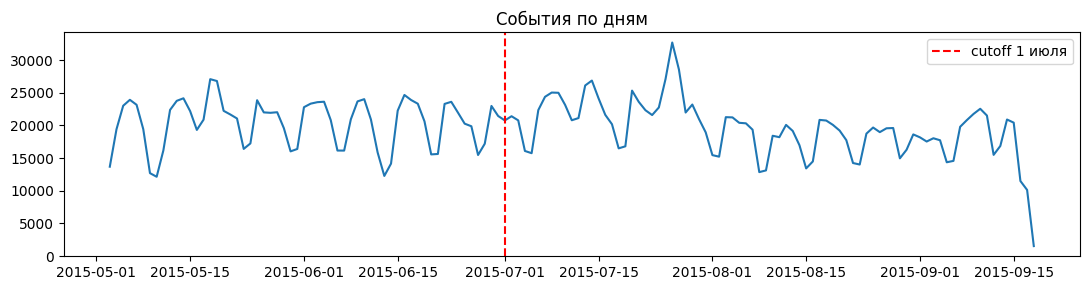

count      139.000000
mean     19824.755396
std       4170.038206
min       1528.000000
25%      16829.500000
50%      20619.000000
75%      22459.500000
max      32692.000000
Name: events, dtype: float64

In [5]:
per_day = eda.events_per_day(itx)
fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(per_day.index, per_day.values)
ax.axvline(pd.Timestamp(cfg.feature_engineering['cutoff']), color='r', ls='--', label='cutoff 1 июля')
ax.set_title('События по дням'); ax.legend()
plt.tight_layout(); plt.show(); plt.close(fig)
per_day.describe()

Поток ровный, ~20 тыс. событий в день, больших провалов нет; крайние дни неполные. Аномальных всплесков не видно.

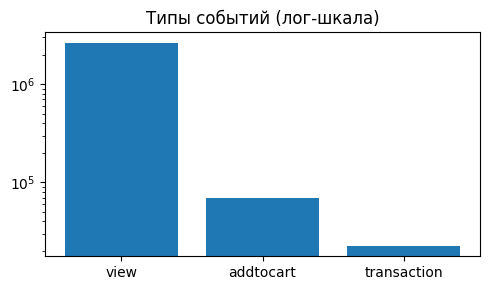

event
view           2664218
addtocart        68966
transaction      22457
Name: count, dtype: Int64

In [6]:
etc = eda.event_type_counts(itx)
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(etc.index.astype(str), etc.values)
ax.set_yscale('log'); ax.set_title('Типы событий (лог-шкала)')
plt.tight_layout(); plt.show(); plt.close(fig)
etc

## 4. Анализ пользователей

In [7]:
epv = eda.events_per_visitor(itx)
ipv = eda.unique_items_per_visitor(itx)
print('событий на визитора: медиана', epv.median(), '| среднее', round(epv.mean(), 2),
      '| максимум', epv.max())
print('доля визиторов с 1 событием:', round((epv == 1).mean(), 3))
print('доля визиторов с >= 2 товарами:', round((ipv >= 2).mean(), 3))
display(eda.user_activity_distribution(itx))

событий на визитора: медиана 1.0 | среднее 1.96 | максимум 7757
доля визиторов с 1 событием: 0.712
доля визиторов с >= 2 товарами: 0.205


,n_interactions,visitors,share
0,1,1001591,0.7116
1,2,206006,0.1464
2,3,79611,0.0566
3,4,38782,0.0276
4,5-10,62023,0.0441
5,11-100,19159,0.0136
6,100+,408,0.0003


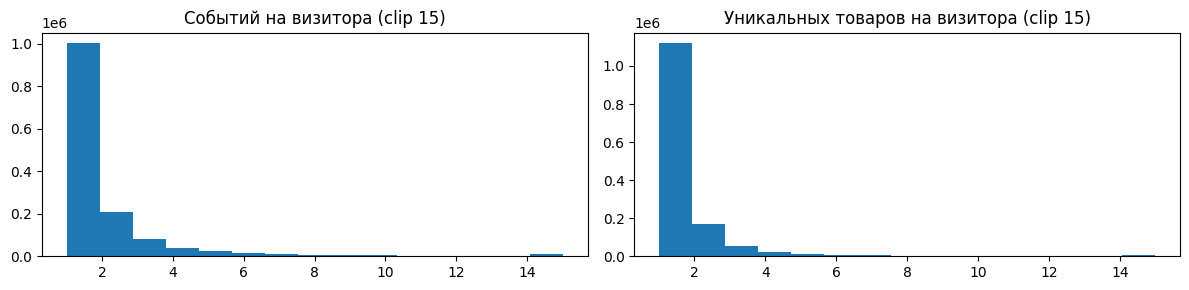

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3))
ax[0].hist(epv.clip(upper=15), bins=15); ax[0].set_title('Событий на визитора (clip 15)')
ax[1].hist(ipv.clip(upper=15), bins=15); ax[1].set_title('Уникальных товаров на визитора (clip 15)')
plt.tight_layout(); plt.show(); plt.close(fig)

Явный long-tail: ~71% визиторов имеют одно событие. Персонализация по истории уверенно оценивается только на меньшинстве (warm-визиторы), остальным нужен fallback. Наиболее активные визиторы:

In [9]:
eda.top_users(itx, k=10)

,visitorid,events,items,transactions
0,1150086,7757,3814,559
1,530559,4328,2209,286
2,152963,3024,1622,349
3,895999,2474,1641,50
4,163561,2410,1314,92
5,371606,2345,1399,94
6,286616,2252,1230,75
7,684514,2246,1187,189
8,892013,2024,1738,0
9,861299,1991,1100,188


## 5. Анализ товаров

товаров: 235061 | доля товаров с 1 событием: 0.313
доля всех событий у топ-100 товаров: 0.036


,n_interactions,items,share
0,1,73616,0.3132
1,2,34830,0.1482
2,3-5,46321,0.1971
3,6-10,29238,0.1244
4,11-50,40158,0.1708
5,50+,10898,0.0464


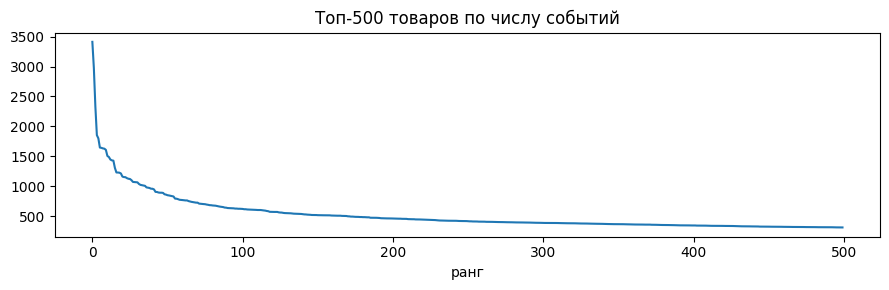

In [10]:
pop = eda.item_popularity(itx)
print('товаров:', len(pop), '| доля товаров с 1 событием:', round((pop == 1).mean(), 3))
print('доля всех событий у топ-100 товаров:', round(pop.head(100).sum() / len(itx), 3))
display(eda.item_popularity_buckets(itx))
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(range(500), pop.head(500).values)
ax.set_title('Топ-500 товаров по числу событий'); ax.set_xlabel('ранг')
plt.tight_layout(); plt.show(); plt.close(fig)

Популярность тоже длиннохвостая, но без сильной концентрации (топ-100 товаров — лишь ~4% событий). ~31% товаров встречаются один раз — для них персональные сигналы почти отсутствуют (item cold-start).

## 6. Анализ транзакций и воронки

,n_baskets,items_per_basket_mean,items_per_basket_median,items_per_basket_max,single_item_baskets_share
0,17672,1.271,1.0,31,0.8467


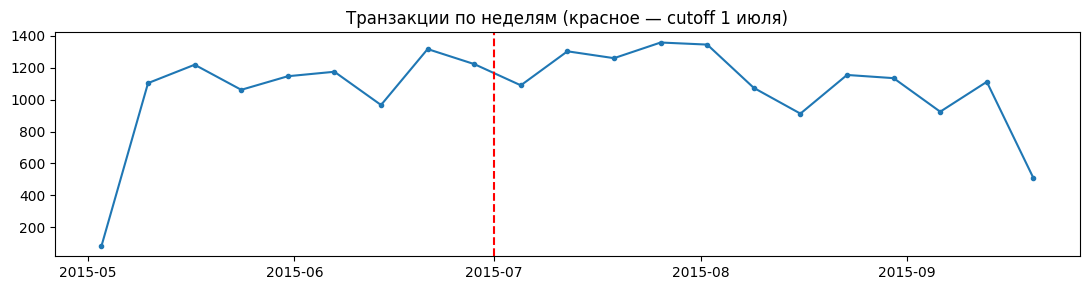

In [11]:
display(eda.basket_stats(itx))
tx_week = eda.transactions_over_time(itx, freq='W')
fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(tx_week.index, tx_week.values, marker='o', ms=3)
ax.axvline(pd.Timestamp(cfg.feature_engineering['cutoff']), color='r', ls='--')
ax.set_title('Транзакции по неделям (красное — cutoff 1 июля)')
plt.tight_layout(); plt.show(); plt.close(fig)

In [12]:
fn = eda.funnel_pair_level(itx)
print(fn)
print('view -> addtocart:', round(fn.loc[1, 'pairs'] / fn.loc[0, 'pairs'], 4))
print('addtocart -> transaction:', round(fn.loc[2, 'pairs'] / fn.loc[1, 'pairs'], 4))

         stage    pairs
0         view  2132127
1    addtocart    62025
2  transaction    21270
view -> addtocart: 0.0291
addtocart -> transaction: 0.3429


Воронка считается по парам (визитор, товар): доля пар, где было каждое действие. Это наличие действия, а не строгая последовательность во времени — трактуем осторожно. Чеки маленькие (в среднем ~1.3 товара).

## 7. Временной анализ и split

Для оценки моделей используется скользящий вперёд split train → validation → test. Для построения признаков — отдельная точка отсечения **1 июля 2015**: признаки строятся из событий до неё, целевое окно — после.

In [13]:
display(describe_windows(itx, cfg))
display(eda.warm_cold_by_window(itx, cfg))

,window,start,end,events,users,items,strong_events,transactions,strong_users,txn_users,cold_users_vs_past,warm_users_vs_past,new_items_vs_past
0,train,2015-05-03,2015-08-21,2200491,1160546,213966,65850,14655,31834,9641,0,1160546,0
1,val,2015-08-22,2015-09-04,237616,141453,71826,7625,1663,3850,1112,127281,14172,9878
2,test,2015-09-05,2015-09-18,224474,133797,68778,6808,1403,3432,983,119678,14119,8781


,window,active_users,warm,cold,cold_share
0,val,141453,14172,127281,0.900
1,test,133797,14119,119678,0.894


In [14]:
cut = pd.Timestamp(cfg.feature_engineering['cutoff'], tz='UTC')
clean = itx[~itx.is_bot]
before = clean[clean.ts < cut]; after = clean[clean.ts >= cut]
print('cutoff 1 июля:')
print('  до :', len(before), 'событий,', before.visitorid.nunique(), 'визиторов,',
      before.itemid.nunique(), 'товаров')
print('  после:', len(after), 'событий,', after.visitorid.nunique(), 'визиторов')
warm_after = len(set(after.visitorid) & set(before.visitorid))
print('  визиторов после cutoff с историей до него (warm):', warm_after,
      '/', after.visitorid.nunique())

cutoff 1 июля:
  до : 1161892 событий, 606714 визиторов, 161570 товаров


  после: 1500689 событий, 834649 визиторов


  визиторов после cutoff с историей до него (warm): 33858 / 834649


Принцип: признаки на момент t считаются только из событий с `ts < t`. Значит, нельзя брать популярность и агрегаты по данным после cutoff, использовать целевое событие в признаках или делать preprocessing на train и test вместе.

## Выводы

1. Данные чистые: пропусков в ключах нет, 460 полных дублей убираются, `transactionid` согласован с типом события.
2. Обратная связь неявная, события сильно несбалансированы (view : addtocart : transaction ≈ 96.7 : 2.5 : 0.8 %).
3. Пользователи крайне разреженные — ~71% с одним событием; персонализация работает на warm-подвыборке, для остальных нужен fallback (популярность).
4. Товары длиннохвостые, ~31% встречаются один раз (item cold-start).
5. Активность во времени ровная — корректны и temporal split, и точка отсечения 1 июля.
6. Категория покрывает ~98% покупаемых товаров — контентные признаки осмысленны.
7. Цены/выручки в данных нет — бизнес-эффект только через прокси (сильные события) и онлайн-эксперимент.